# Heart Failure Clinical Records
Contains medical records of 299 patients who had heart failure. Data was collected during a follow-up period

Each patient has 13 clinical features.

# Citation:
"Heart Failure Clinical Records," UCI Machine Learning Repository, 2020. [Online]. Available: https://doi.org/10.24432/C5Z89R.

In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_failure_clinical_records = fetch_ucirepo(id=519)

# data (as pandas dataframes)
X = heart_failure_clinical_records.data.features
y = heart_failure_clinical_records.data.targets

df = heart_failure_clinical_records.data.features

CONTINUOUS_FEATURES = ["age",
                       "creatinine_phosphokinase",
                       "ejection_fraction",
                       "platelets",
                       "serum_creatinine",
                       #"time",
                       "serum_sodium"]
                       # omit time because it's not used in prediction

BINARY_FEATURES = ["anaemia",
                   "diabetes",
                   "high_blood_pressure",
                   "sex",
                   "smoking"]

TARGET = ["DEATH_EVENT"]

df['DEATH_EVENT'] = heart_failure_clinical_records.data.targets



# Exploratory Data Analysis (EDA)
Goal: Understand the distribution and characteristics of features, both univariate, bivariate and multivariate.

In [ ]:
df.shape

(299, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**Dataset Understanding**

No missing/Nan values
features are already converted to binary

In [ ]:
df.describe(include='all')

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [ ]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
df.nunique()

,0
age,47
anaemia,2
creatinine_phosphokinase,208
diabetes,2
ejection_fraction,17
high_blood_pressure,2
platelets,176
serum_creatinine,40
serum_sodium,27
sex,2


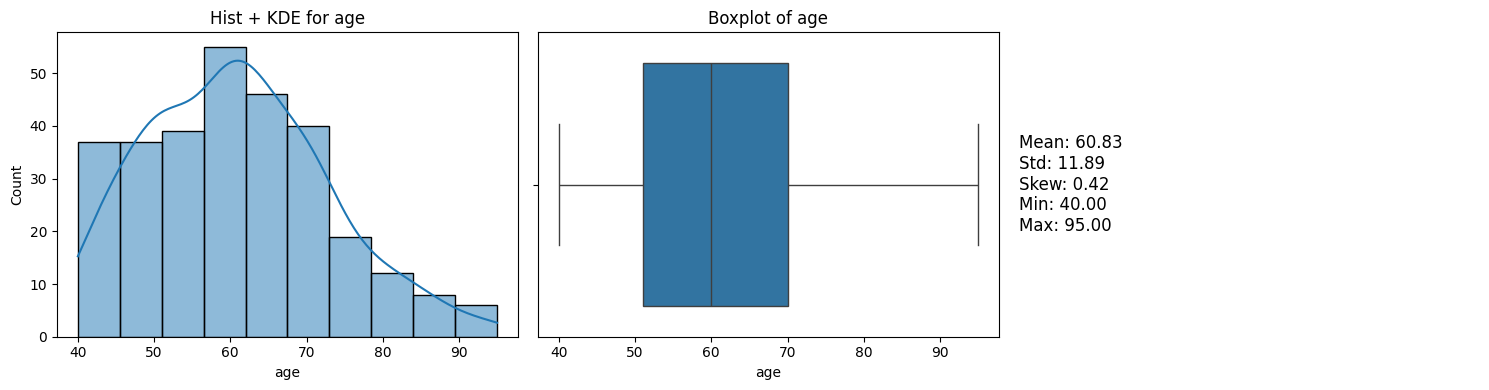

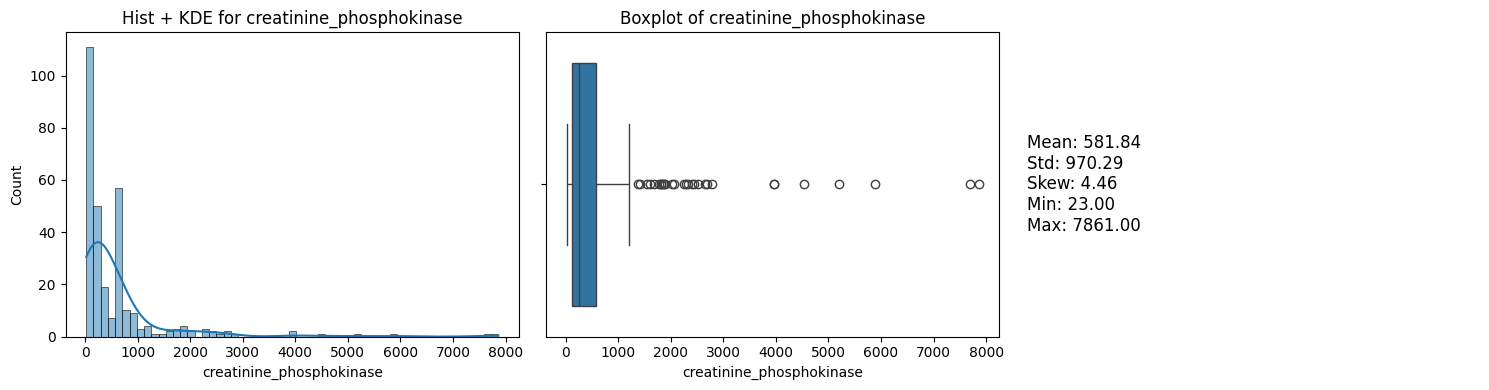

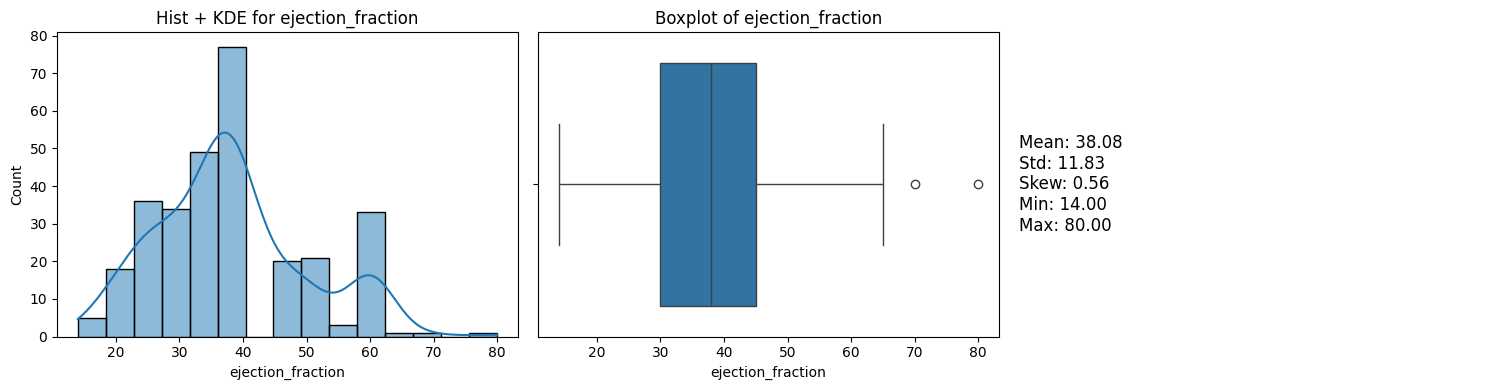

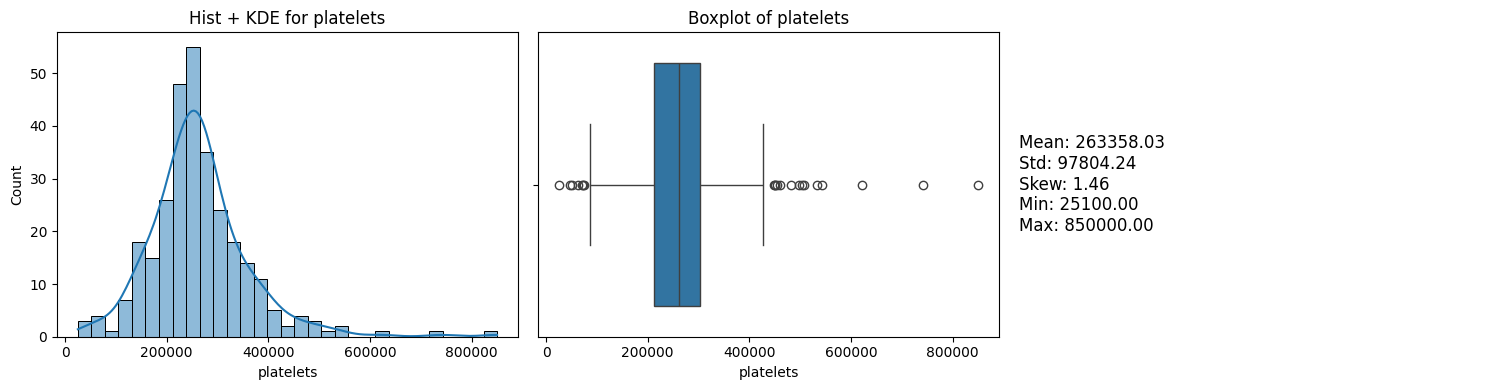

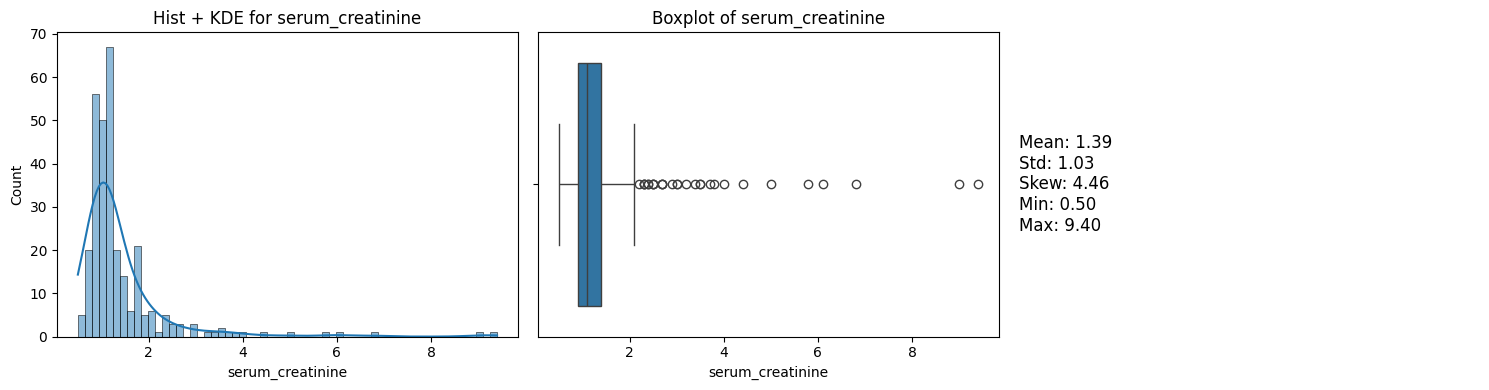

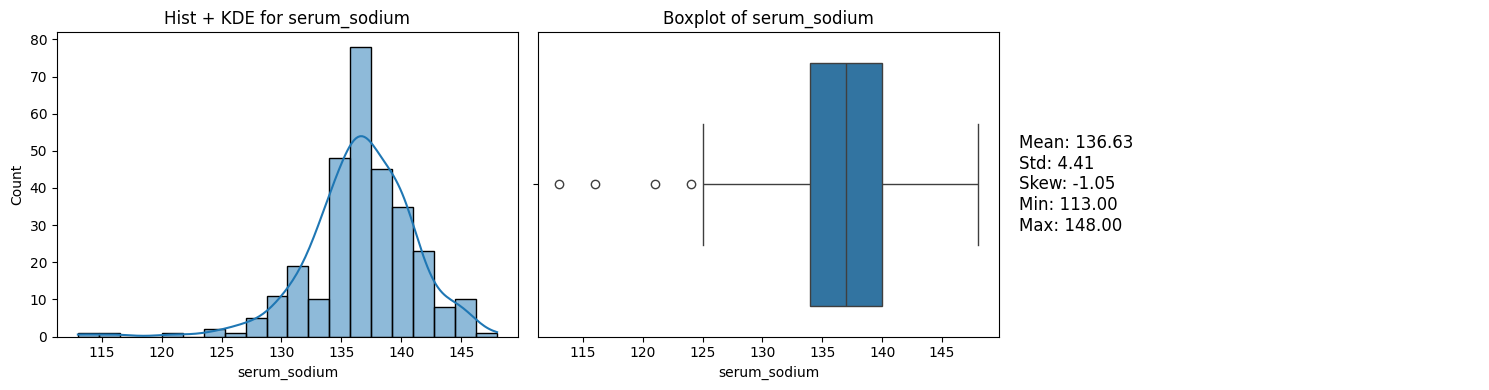

In [ ]:
# univariate analysis of continuous features
for col in CONTINUOUS_FEATURES:
  fig, axes = plt.subplots(1, 3, figsize=(15,4))

  # Histrogram + KDE (shows general shape)
  sns.histplot(data=df[col], kde=True, ax=axes[0])
  axes[0].set_title(f'Hist + KDE for {col}')

  # Boxplot (shows quartiles & outliers)
  sns.boxplot(x=df[col], ax=axes[1])
  axes[1].set_title(f'Boxplot of {col}')

  stats = df[col].describe()
  axes[2].axis('off')
  axes[2].text(0, 0.5, f"Mean: {stats['mean']:.2f}\n"
                         f"Std: {stats['std']:.2f}\n"
                         f"Skew: {df[col].skew():.2f}\n"
                         f"Min: {stats['min']:.2f}\n"
                         f"Max: {stats['max']:.2f}",
                 fontsize=12, va='center')

  plt.tight_layout()
  plt.show

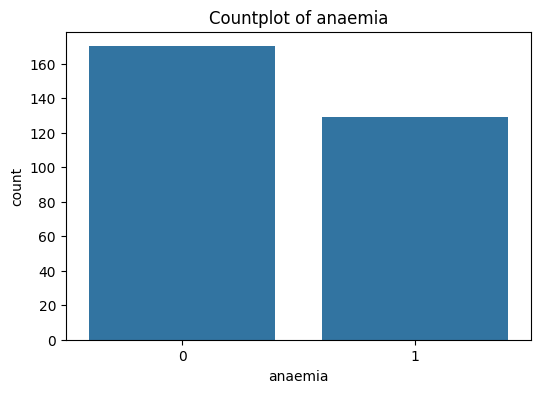

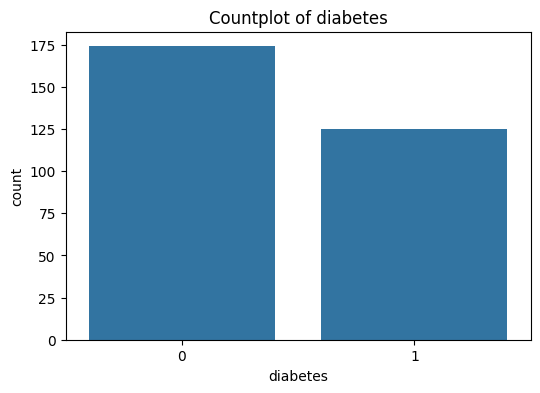

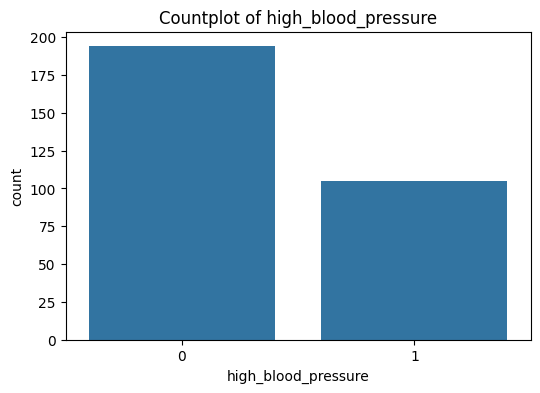

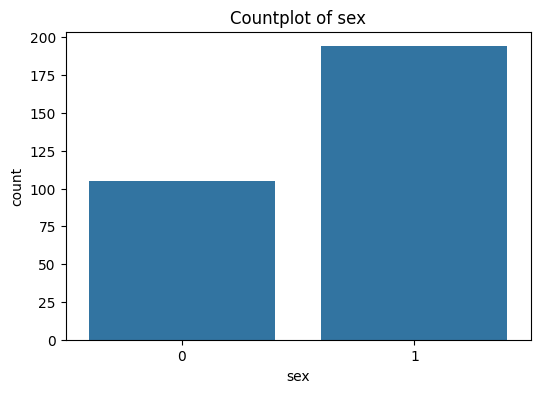

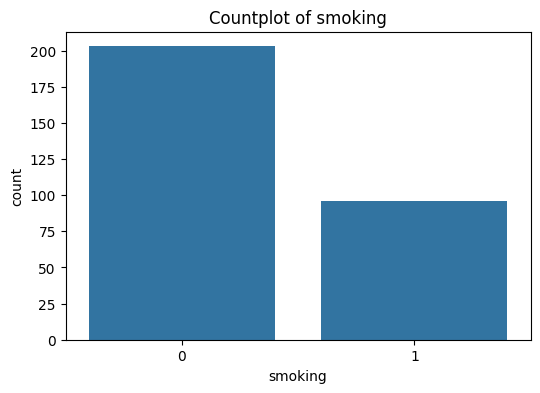

In [ ]:
# univariate analysis of binary features
for col in BINARY_FEATURES:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df , x=col)
  plt.title(f'Countplot of {col}')
  plt.show()

## Bivariate Analysis

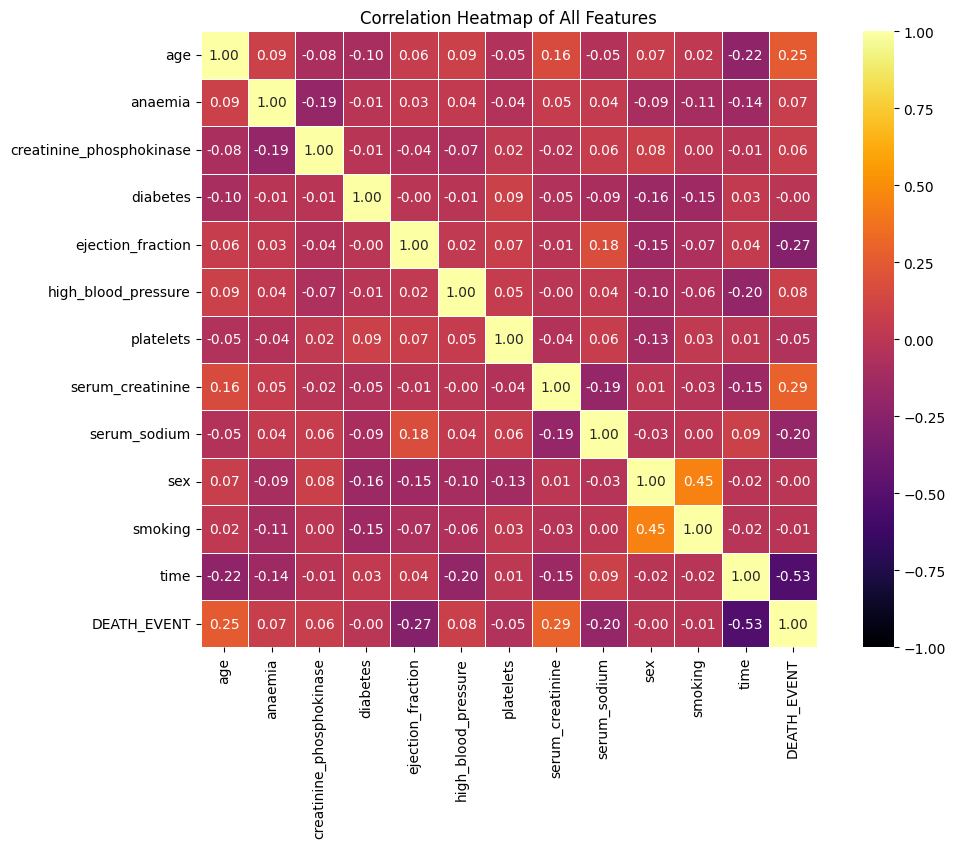

In [ ]:
corr = df.corr(numeric_only=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="inferno",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap of All Features")
plt.show()

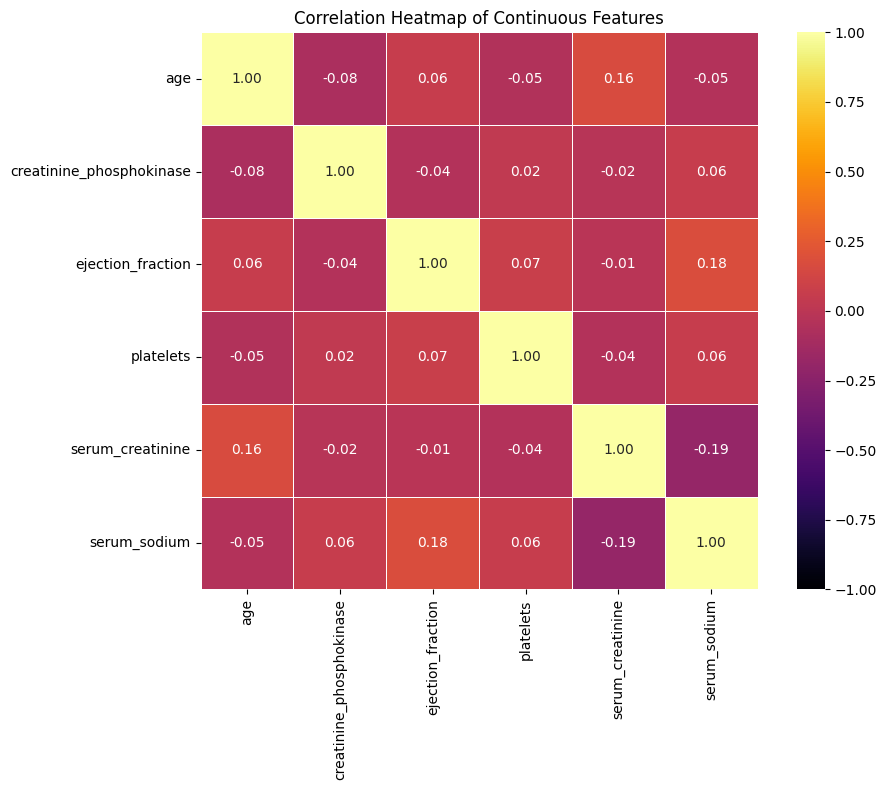

In [ ]:
# compute correlation matrix
corr = df[CONTINUOUS_FEATURES].corr()

# plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    cmap="inferno",   # color scheme
    fmt=".2f",         # two decimal places
    vmin=-1, vmax=1,   # color range
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Continuous Features")
plt.tight_layout()
plt.show()

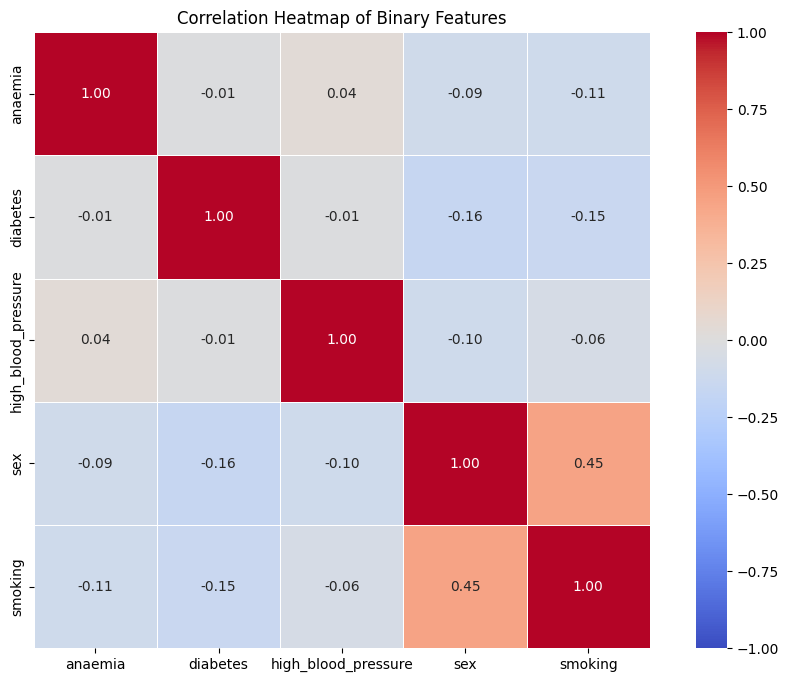

In [ ]:
corr = df[BINARY_FEATURES].corr(numeric_only=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap of Binary Features")
plt.show()

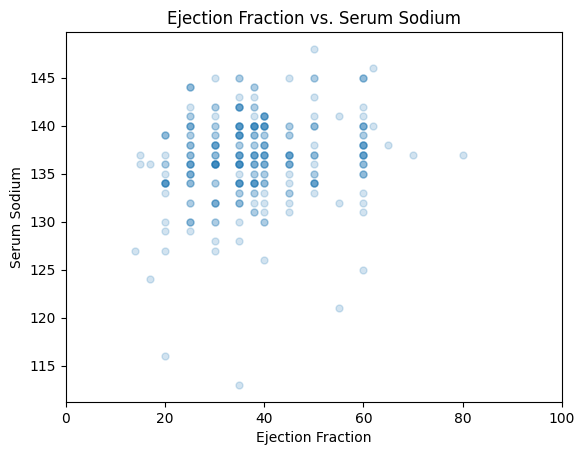

In [ ]:
plt.scatter(data=df, x='ejection_fraction', y='serum_sodium', alpha=0.2, s=25)
plt.xlim(xmin=0, xmax=100)

plt.xlabel('Ejection Fraction')
plt.ylabel('Serum Sodium')
plt.title('Ejection Fraction vs. Serum Sodium')

plt.show()

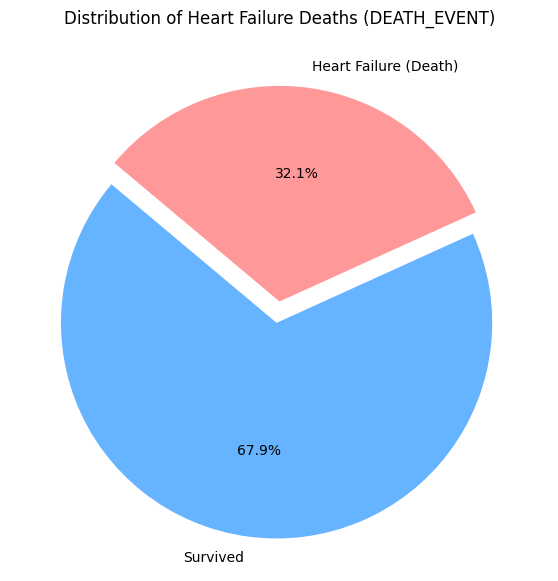

In [ ]:
# Visualize the target variable distribution
death_event_counts = df['DEATH_EVENT'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    death_event_counts,
    labels=['Survived', 'Heart Failure (Death)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#ff9999'],
    explode=(0.1, 0) # explode the first slice
)
plt.title('Distribution of Heart Failure Deaths (DEATH_EVENT)')
plt.show()

### Overall Take-aways from EDA

- Work-in-Progress

# Data Pre-Processing
As seen before, our data contains two different data types, continuous data and binary data.

## Train-Test-Validation Split
We will split our data into two non-overlapping subsets:
- Train: 80%
- Test: 20%

**Two subset split**:
Without a validation set, we will have no way to tune hyperparameters without looking at the test set. We should be looking at the test set once, and thats at the very end.

Scikit-learn's 'train_test_split' can only split into two groups at a time. To get our three groups, we split a second time.

**Stratification:** Both splits use 'stratify=y', ensuring that they preserve the same ~32% death ratio. Without it, one of our subsets could end up with only patients that lived, or only patients that didn't.

## Feature Scaling
Neural networks are sensitive. Features that have data in which their ranges differ too greatly would result in exploding gradients (gradients that are of magnitudes larger.)

**StandardScaler** fixes this by taking the input X and subtracting its mean, then dividing the result by its standard deviation.

The scaler is fit on **only the training set**. If we fit the scaler on the full dataset, the model would indirectly learn from the validation and test set, resulting in something called **data leakage**, then causing overfitting.

Only continuous data is scaled.




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [ ]:
def load_data(
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_state: int = 42,
) -> dict:

    feature_names = CONTINUOUS_FEATURES + BINARY_FEATURES
    X = df[feature_names].values.astype(np.float32)
    y = df[TARGET].values.astype(np.float32).ravel()

    # 1) Split first (avoid leakage)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    relative_val = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=relative_val,
        random_state=random_state, stratify=y_trainval
    )

    cont_idx = list(range(len(CONTINUOUS_FEATURES)))
    bin_idx = list(range(len(CONTINUOUS_FEATURES), len(feature_names)))

    # 2) Preprocess: Box-Cox (continuous) -> Standardize; passthrough binary
    # NOTE: Box-Cox requires all continuous values > 0.
    cont_pipe = Pipeline(steps=[
        ("boxcox", PowerTransformer(method="box-cox", standardize=False)),
        ("scaler", StandardScaler()),
    ])

 # takes continuous features and apply transformation to this only, leave binary features unchanged
    preprocessor = ColumnTransformer(
        transformers=[
            ("cont", cont_pipe, cont_idx),
            ("bin", "passthrough", bin_idx),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    # 3) Fit on TRAIN only; transform val/test
    X_train = preprocessor.fit_transform(X_train)
    X_val = preprocessor.transform(X_val)
    X_test = preprocessor.transform(X_test)

    # Ensure float32 output (some sklearn ops return float64)
    X_train = X_train.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_test = X_test.astype(np.float32)

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "preprocessor": preprocessor,
        "feature_names": feature_names,
    }

# Logistic Regression



In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

In [ ]:
scores = []
metrics = ['Recall', 'Precision', 'F1']

Using GridSearchCV to find the best combinations of parameters. Parameters were chosen by importance3 as described on the Logistic Regression page on the scikit-learn site: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Set up parameters for GridSearchCV
params = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0], # For regularization; limiting overfitting
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'], # Solver used to minimize loss function
    'class_weight': [None, 'balanced'] # Assigns importance to classes
}

# Load transformed data into 'data' variable
lr_data = load_data()

Utilize grid search with cv=10 to find the best model for the following three metrics: recall, precision, and F1

In [ ]:
recall_logRegr = LogisticRegression()

grid_search_recall_logRegr = GridSearchCV(estimator=recall_logRegr, param_grid=params, cv=10, scoring='recall')
grid_search_recall_logRegr.fit(lr_data['X_train'], lr_data['y_train'])

print("Best Parameters:", grid_search_recall_logRegr.best_params_, "Best Recall Score:", grid_search_recall_logRegr.best_score_)
scores.append(grid_search_recall_logRegr.best_score_)

logRegr = grid_search_recall_logRegr.best_estimator_

Best Parameters: {'C': 1.0, 'class_weight': 'balanced', 'solver': 'liblinear'} Best Recall Score: 0.7766666666666666


In [ ]:
precision_logRegr = LogisticRegression()

grid_search_precision_logRegr = GridSearchCV(estimator=precision_logRegr, param_grid=params, cv=10, scoring='precision')
grid_search_precision_logRegr.fit(lr_data['X_train'], lr_data['y_train'])

print("Best Parameters:", grid_search_precision_logRegr.best_params_, "Best Precision Score:", grid_search_precision_logRegr.best_score_)
scores.append(grid_search_precision_logRegr.best_score_)

Best Parameters: {'C': 0.01, 'class_weight': None, 'solver': 'liblinear'} Best Precision Score: 0.7183333333333334


In [ ]:
f1_logRegr = LogisticRegression()

grid_search_f1_logRegr = GridSearchCV(estimator=f1_logRegr, param_grid=params, cv=10, scoring='f1')
grid_search_f1_logRegr.fit(lr_data['X_train'], lr_data['y_train'])

print("Best Parameters:", grid_search_f1_logRegr.best_params_, "Best F1 Score:", grid_search_f1_logRegr.best_score_)
scores.append(grid_search_f1_logRegr.best_score_)

Best Parameters: {'C': 1.0, 'class_weight': 'balanced', 'solver': 'liblinear'} Best F1 Score: 0.6778971028971029


F1 and recall have the same parameter setting for their best model, so the "best" overall model can be either of them. Don't want to use precision as we want to optimize recall (precision-recall trade-off)

Lets use charts to analyze results

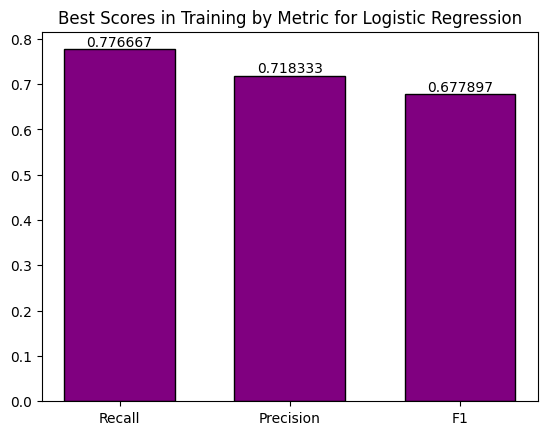

In [ ]:
bars = plt.bar(metrics, scores, color='purple', edgecolor='black', width=0.65)
plt.bar_label(bars)
plt.title("Best Scores in Training by Metric for Logistic Regression")
plt.show()

Classification Reports:
               precision    recall  f1-score   support

         0.0       0.76      0.68      0.72        41
         1.0       0.43      0.53      0.48        19

    accuracy                           0.63        60
   macro avg       0.60      0.60      0.60        60
weighted avg       0.65      0.63      0.64        60



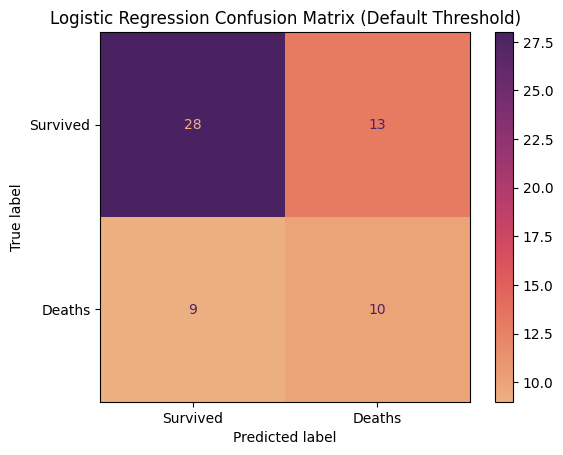

Testing Set Results (Default Threshold)
Precision: 0.43
Recall: 0.53
F1 Score: 0.48


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Get predictions for testing set
lr_y_pred = logRegr.predict(lr_data['X_test'])

# Get classification report
logRegr_report = classification_report(lr_data['y_test'], lr_y_pred)
print("Classification Reports:\n", logRegr_report)

# Generate a confusion matrix
cm = confusion_matrix(lr_data['y_test'], lr_y_pred)
disp_logRegr = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Deaths'])
disp_logRegr.plot(cmap='flare')
plt.title("Logistic Regression Confusion Matrix (Default Threshold)")
plt.show()

# Get metric scores
precision = precision_score(lr_data['y_test'], lr_y_pred)
recall = recall_score(lr_data['y_test'], lr_y_pred)
f1 = f1_score(lr_data['y_test'], lr_y_pred)

# Print metric scores
print("Testing Set Results (Default Threshold)")
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

Scores are much higher in the survived class (0.0) class than the death class (1.0), which is likely due to the class imbalance within the dataset.

The confusion matrix shows 28 TNs, but only 10 TPs and 9 FNs. In medical setting, FNs need to be lowered.

Recall and F1 Score decreased compared to grid search results (during training). This indicates overfitting which is most likely caused by the dataset being too small.

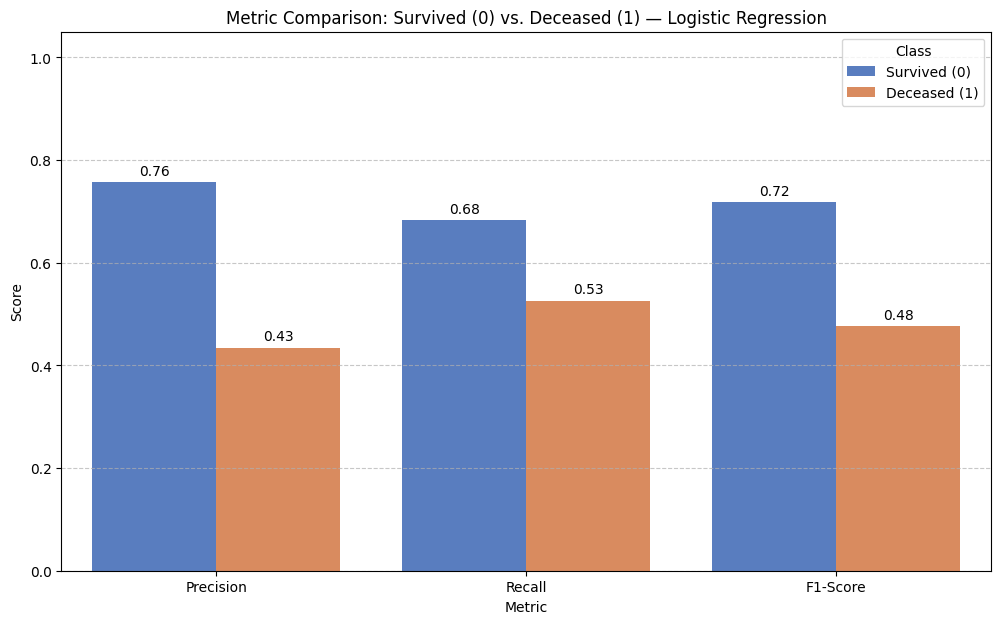

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Generate bare graph to compare each metric by class
metrics_per_class = precision_recall_fscore_support(lr_data['y_test'], lr_y_pred, labels=[0, 1])

# Axis labels
data_list = []
labels = ['Survived (0)', 'Deceased (1)']
metric_names = ['Precision', 'Recall', 'F1-Score']

for i, label in enumerate(labels):
    for j, metric in enumerate(metric_names):
        data_list.append({
            'Class': label,
            'Metric': metric,
            'Score': metrics_per_class[j][i]
        })

metrics_df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', palette='muted')

plt.ylim(0, 1.05)
plt.title('Metric Comparison: Survived (0) vs. Deceased (1) — Logistic Regression')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in plt.gca().containers:
    plt.gca().bar_label(bar, fmt='%.2f', padding=3)

plt.show()

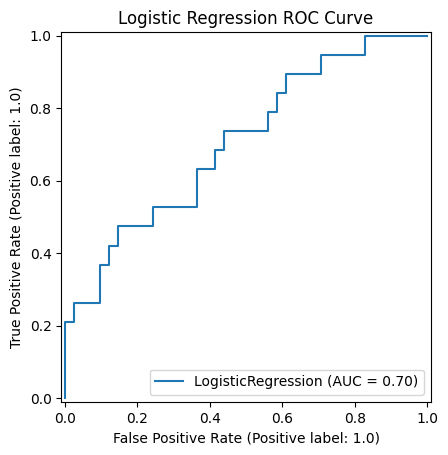

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Generate ROC Curve
RocCurveDisplay.from_estimator(logRegr, lr_data['X_test'], lr_data['y_test'])
plt.title("Logistic Regression ROC Curve")
plt.show()

A ROC AUC score of 0.70 indicates the model is performing better than randomly guessing outcomes (a score of 0.5). The model is obviously learning patterns, but there is room for improvement. A larger dataset or different set of data transformations could increase this score.

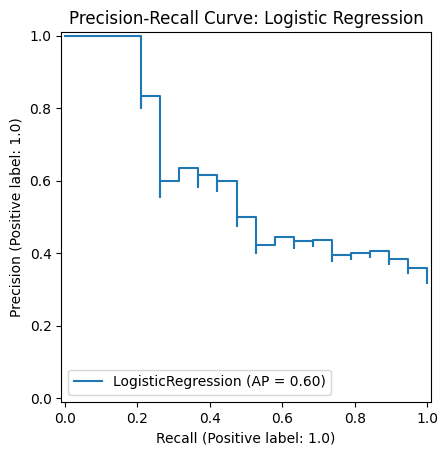

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Generate a precision-recall curve
PrecisionRecallDisplay.from_estimator(logRegr, lr_data['X_test'], lr_data['y_test'])

plt.title("Precision-Recall Curve: Logistic Regression")
plt.show()

The precision-recall curve illustrates the precision-recall curve of the model and shows that a lower-threshold exists where the recall can be maximized from the current 0.53 to close to 1.0. Increasing the recall will also lower the total FNs and maybe increase TPs

              precision    recall  f1-score   support

         0.0       0.79      0.56      0.66        41
         1.0       0.42      0.68      0.52        19

    accuracy                           0.60        60
   macro avg       0.61      0.62      0.59        60
weighted avg       0.67      0.60      0.61        60



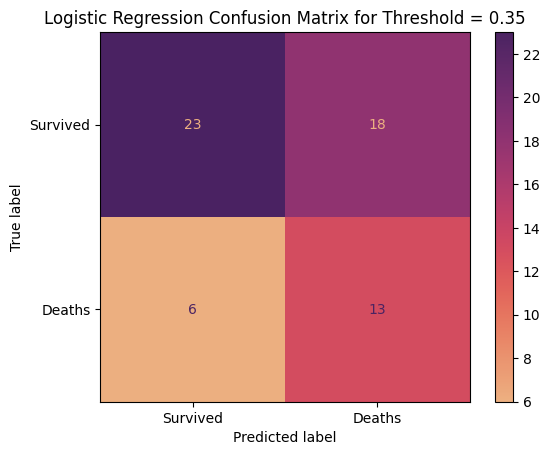

At Threshold 0.35
Precision: 0.42
Recall: 0.68
F1 Score: 0.52


In [ ]:
# Lowering the threshold to increase recall, decrease false negatives
lr_y_probs = logRegr.predict_proba(lr_data['X_test'])[:, 1]

# Lower threshold from default 0.5
new_threshold = 0.35

# Update predictions for new threshold
lr_y_pred_new_threshold = (lr_y_probs >= new_threshold).astype(int)

# Get classification report
print(classification_report(lr_data['y_test'], lr_y_pred_new_threshold))

# Generate new confusion matrix
cm = confusion_matrix(lr_data['y_test'], lr_y_pred_new_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Deaths'])
disp.plot(cmap='flare')
cm_title = "Logistic Regression Confusion Matrix for Threshold = " + str(new_threshold)
plt.title(cm_title)
plt.show()

# Retrieve metric scores
precision = precision_score(lr_data['y_test'], lr_y_pred_new_threshold)
recall = recall_score(lr_data['y_test'], lr_y_pred_new_threshold)
f1 = f1_score(lr_data['y_test'], lr_y_pred_new_threshold)


# Print metric scores
print("At Threshold", new_threshold)
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

A threshold of 0.35 or 35% was found to be the "sweet spot" as it decreases the FNs and increases TPs, but doesn't increase FPs too much and doesn't decrease TNs too much. It increases recall while allowing overall results to remain reliable.

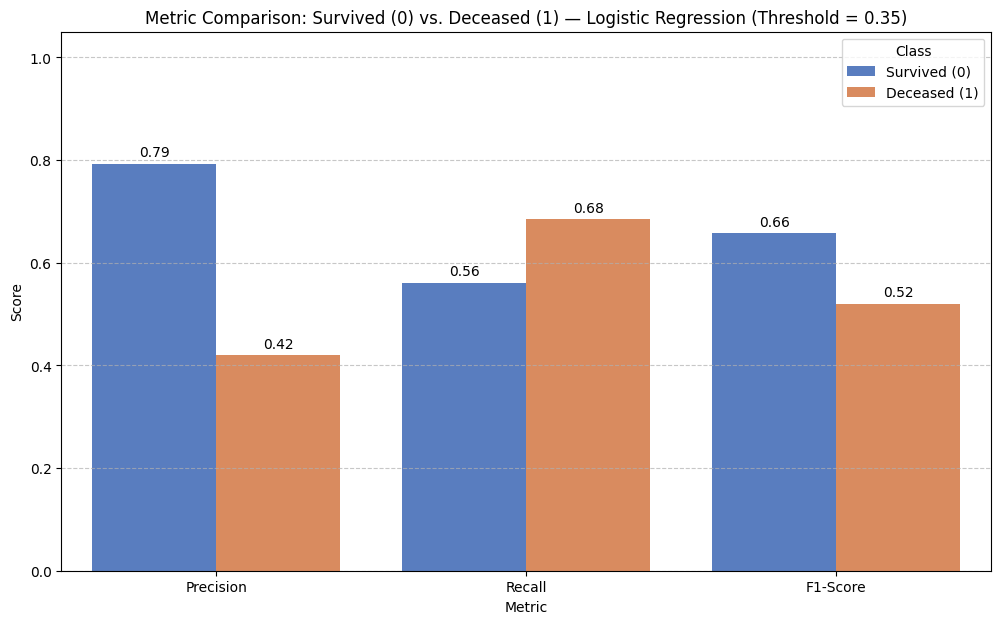

In [ ]:
# Generate bar graph to compare each metric by class
metrics_per_class = precision_recall_fscore_support(lr_data['y_test'], lr_y_pred_new_threshold, labels=[0, 1])

# Axis labels
data_list = []
labels = ['Survived (0)', 'Deceased (1)']
metric_names = ['Precision', 'Recall', 'F1-Score']

for i, label in enumerate(labels):
    for j, metric in enumerate(metric_names):
        data_list.append({
            'Class': label,
            'Metric': metric,
            'Score': metrics_per_class[j][i]
        })

metrics_df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', palette='muted')

plt.ylim(0, 1.05)
plt.title('Metric Comparison: Survived (0) vs. Deceased (1) — Logistic Regression (Threshold = 0.35)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in plt.gca().containers:
    plt.gca().bar_label(bar, fmt='%.2f', padding=3)

plt.show()

A lower threshold, such as 0.1 (10%), would produce unreliable results.

              precision    recall  f1-score   support

         0.0       0.89      0.20      0.32        41
         1.0       0.35      0.95      0.51        19

    accuracy                           0.43        60
   macro avg       0.62      0.57      0.42        60
weighted avg       0.72      0.43      0.38        60



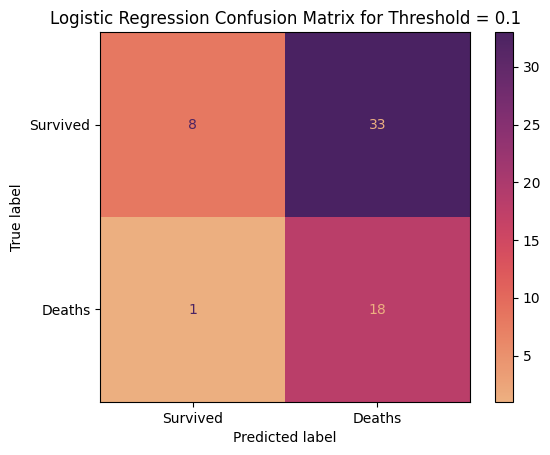

At Threshold 0.1
Precision: 0.35
Recall: 0.95
F1 Score: 0.51


In [ ]:
# Lowering the threshold to increase recall, decrease false negatives
lr_y_probs = logRegr.predict_proba(lr_data['X_test'])[:, 1]

# Lower threshold from default 0.5
new_threshold = 0.1

# Update predictions for new threshold
lr_y_pred_new_threshold = (lr_y_probs >= new_threshold).astype(int)

# Get classification report
print(classification_report(lr_data['y_test'], lr_y_pred_new_threshold))

# Generate new confusion matrix
cm = confusion_matrix(lr_data['y_test'], lr_y_pred_new_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Deaths'])
disp.plot(cmap='flare')
cm_title = "Logistic Regression Confusion Matrix for Threshold = " + str(new_threshold)
plt.title(cm_title)
plt.show()

# Retrieve metric scores
precision = precision_score(lr_data['y_test'], lr_y_pred_new_threshold)
recall = recall_score(lr_data['y_test'], lr_y_pred_new_threshold)
f1 = f1_score(lr_data['y_test'], lr_y_pred_new_threshold)


# Print metric scores
print("At Threshold", new_threshold)
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

While recall is a high 0.95, precision has fallen to 0.35 and F1 is 0.51. There is only 1 FN, but TN has fallen to 8 and FPs has risen all the way to 33. Overall, this threshold doesn't produce results as reliable as threshold 0.35.

Regardless, this shows the logistic regression model has an advantage over the neural network (at the end of the notebook) since a lower threshold in NN produces runreliable results instantly, but a lower threshold can still produce reliable results for a logistic regression model.

# SVC

In [ ]:
from sklearn.svm import SVC

Set up grid search to find the best combination of parameter values to find the optimal model for precision, recall, and F1

In [ ]:
# get data
data = load_data()

In [ ]:
svm_scores = []

svm_params = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

gs_f1 = None

for metric in ['recall', 'precision', 'f1']:
  svm = SVC(probability=True, random_state=42)
  gs = GridSearchCV(estimator=svm, param_grid=svm_params, cv=10, scoring=metric)
  gs.fit(data['X_train'], data['y_train'])

  print(f"[{metric}] Best params: {gs.best_params_} | Score: {gs.best_score_:.4f}")
  svm_scores.append(gs.best_score_)

  if metric == 'f1':
    gs_f1 = gs

best_svm = gs_f1.best_estimator_

[recall] Best params: {'C': 1.0, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'} | Score: 0.7600
[precision] Best params: {'C': 0.1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'} | Score: 0.7300
[f1] Best params: {'C': 1.0, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'} | Score: 0.6630


Get classification report to analyze SVC results

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = best_svm.predict(data['X_test'])
y_prob = best_svm.predict_proba(data['X_test'])[:,1]

print(classification_report(data['y_test'], y_pred))
svm_report = classification_report(data['y_test'], y_pred)

print("ROC-AUC", roc_auc_score(data['y_test'], y_prob))
print(confusion_matrix(data['y_test'], y_pred))


              precision    recall  f1-score   support

         0.0       0.76      0.71      0.73        41
         1.0       0.45      0.53      0.49        19

    accuracy                           0.65        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.67      0.65      0.66        60

ROC-AUC 0.7329910141206675
[[29 12]
 [ 9 10]]


The report shows scores higher in the survived class, likely due to data imbalance in the target class. A high ROC-AUC is promising.

Visualize ROC Curve

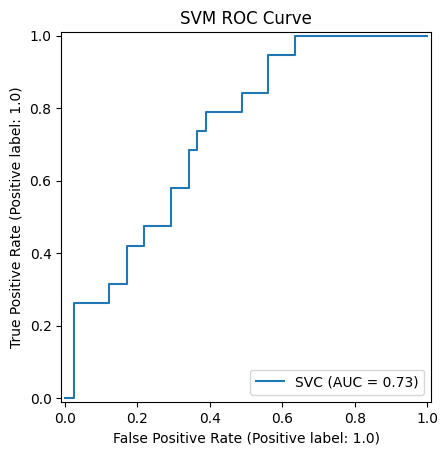

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_svm, data['X_test'], data['y_test'])
plt.title("SVM ROC Curve")
plt.show()

A ROC AUC score of ~0.73 shows the model did learn patterns and performed slightly better than logistic regression based on the same metric, but again there is room for improvement.

Generate confusion matrix to see TPs, TNs, FPs, FNs

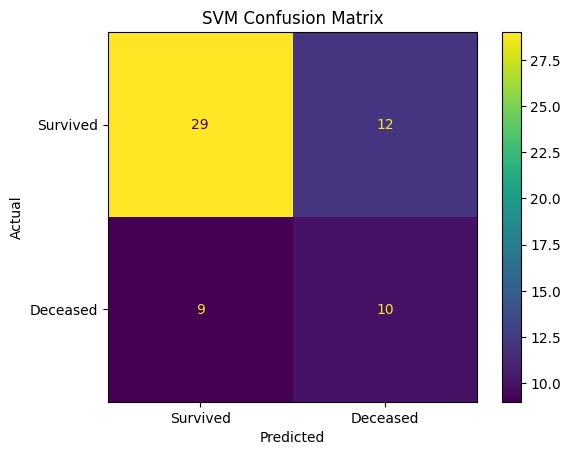

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_svm,
    data['X_test'],
    data['y_test'],
    display_labels=['Survived', 'Deceased']
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model only predicts half of death cases, which is less than ideal as there are 9 FNs.

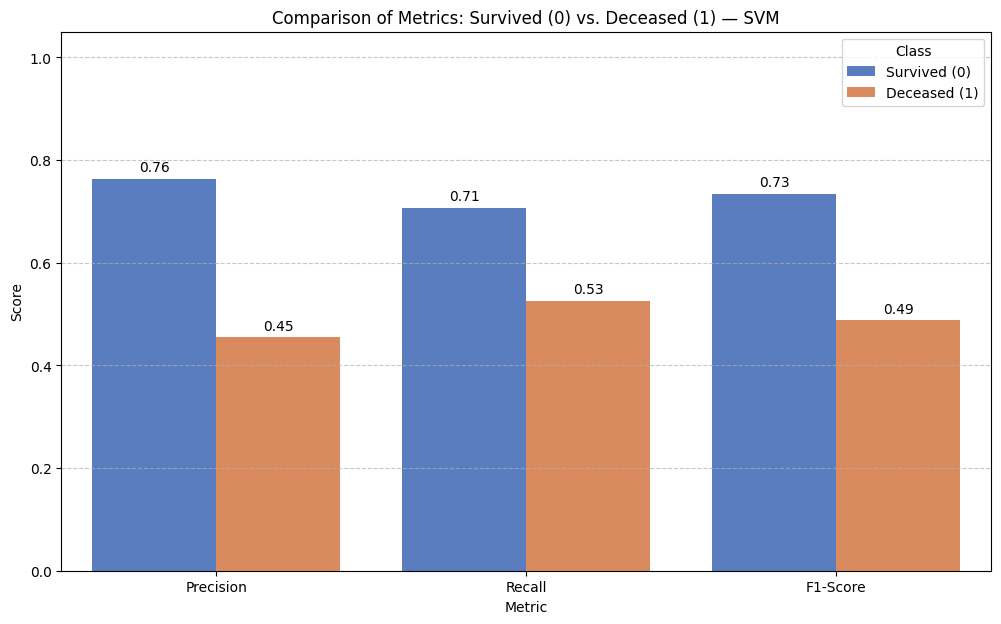

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Use SVM predictions
metrics_per_class = precision_recall_fscore_support(data['y_test'], y_pred, labels=[0, 1])

data_list = []
labels = ['Survived (0)', 'Deceased (1)']
metric_names = ['Precision', 'Recall', 'F1-Score']

for i, label in enumerate(labels):
    for j, metric in enumerate(metric_names):
        data_list.append({
            'Class': label,
            'Metric': metric,
            'Score': metrics_per_class[j][i]
        })

metrics_df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', palette='muted')

plt.ylim(0, 1.05)
plt.title('Comparison of Metrics: Survived (0) vs. Deceased (1) — SVM')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.show()

# RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV



rf_features = [
    "serum_creatinine",
    "serum_sodium",
    "ejection_fraction",
    "age",
    "high_blood_pressure"
]

X_rf = df[rf_features].values.astype(np.float32)
y_rf = df[TARGET].values.astype(np.float32).ravel()


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)


scaler_rf = StandardScaler()
X_train_scaled = scaler_rf.fit_transform(X_train_rf)
X_test_scaled = scaler_rf.transform(X_test_rf)

rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}


rf_clf = RandomForestClassifier(random_state=42)
gs_rf = GridSearchCV(estimator=rf_clf, param_grid=rf_params, cv=5, scoring='recall', n_jobs=-1)
gs_rf.fit(X_train_scaled, y_train_rf)

best_rf = gs_rf.best_estimator_
print(f"Best Parameters: {gs_rf.best_params_}")
print(f"Best Cross-Validation Recall Score: {gs_rf.best_score_:.4f}")


X_test_rf = X_test_scaled

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation Recall Score: 0.6350


Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.80      0.82        41
         1.0       0.62      0.68      0.65        19

    accuracy                           0.77        60
   macro avg       0.73      0.74      0.74        60
weighted avg       0.77      0.77      0.77        60



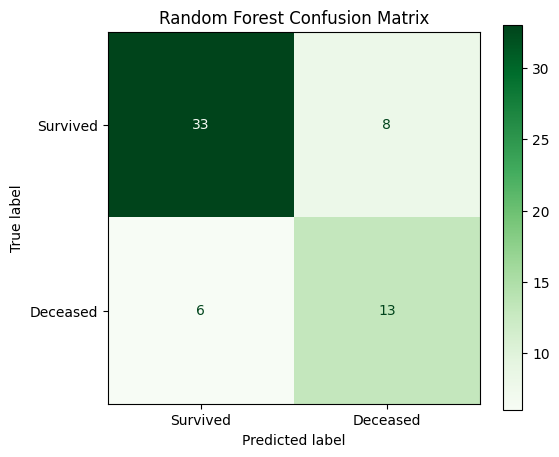

In [ ]:

y_pred_rf = best_rf.predict(X_test_scaled)

print("Random Forest Classification Report:")
rf_report = classification_report(y_test_rf, y_pred_rf)
print(rf_report)


fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test_scaled,
    y_test_rf,
    display_labels=['Survived', 'Deceased'],
    cmap='Greens',
    ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

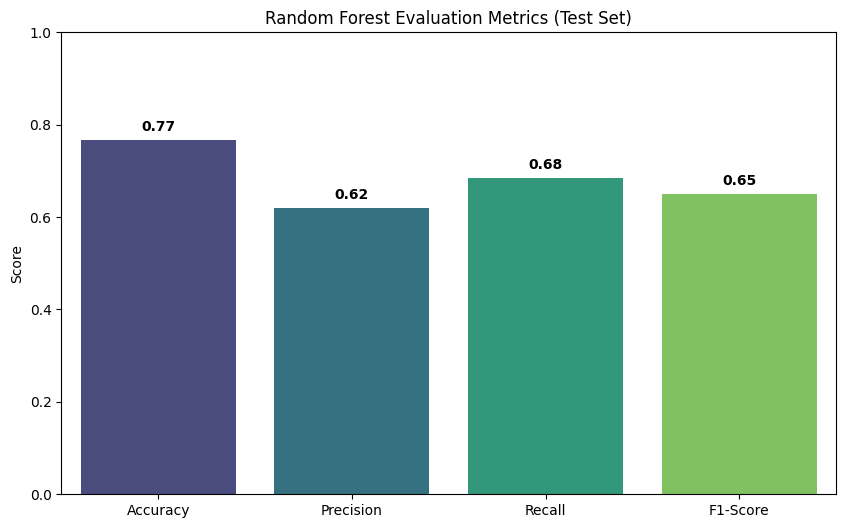

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


rf_accuracy = accuracy_score(y_test_rf, y_pred_rf)
rf_precision = precision_score(y_test_rf, y_pred_rf)
rf_recall = recall_score(y_test_rf, y_pred_rf)
rf_f1 = f1_score(y_test_rf, y_pred_rf)

rf_metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_metrics_values = [rf_accuracy, rf_precision, rf_recall, rf_f1]


plt.figure(figsize=(10, 6))
sns.barplot(x=rf_metrics_names, y=rf_metrics_values, hue=rf_metrics_names, palette='viridis', legend=False)


plt.ylim(0, 1.0)
plt.title('Random Forest Evaluation Metrics (Test Set)')
plt.ylabel('Score')
for i, v in enumerate(rf_metrics_values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

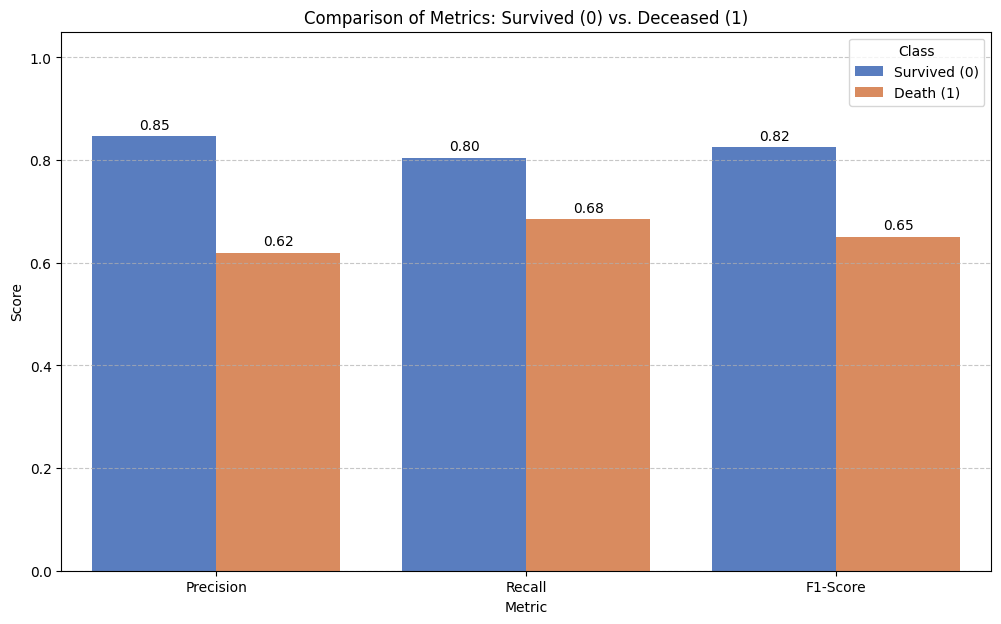

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Calculate metrics for both classes using the consistent y_test_rf and y_pred_rf
metrics_per_class = precision_recall_fscore_support(y_test_rf, y_pred_rf, labels=[0, 1])

# Prepare data for plotting
data_list = []
labels = ['Survived (0)', 'Death (1)']
metric_names = ['Precision', 'Recall', 'F1-Score']

for i, label in enumerate(labels):
    for j, metric in enumerate(metric_names):
        data_list.append({
            'Class': label,
            'Metric': metric,
            'Score': metrics_per_class[j][i]
        })

metrics_df = pd.DataFrame(data_list)

# Plotting the double bar chart
plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', palette='muted')

plt.ylim(0, 1.05)
plt.title('Comparison of Metrics: Survived (0) vs. Deceased (1)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.show()

# Random Forest with Random Undersampling
In this section, we explicitly balance the training data classes using undersampling before training the Random Forest model.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# 1. Prepare data (using the same feature set)
rf_features = ["serum_creatinine", "serum_sodium", "ejection_fraction", "age", "high_blood_pressure"]
X_rus = df[rf_features].values.astype(np.float32)
y_rus = df[TARGET].values.astype(np.float32).ravel()

X_train_rus_raw, X_test_rus_raw, y_train_rus, y_test_rus = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42, stratify=y_rus
)

# 2. Apply Random Undersampling to Training Data
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_rus_raw, y_train_rus)

# 3. Scale the data
scaler_rus = StandardScaler()
X_train_rus_scaled = scaler_rus.fit_transform(X_train_resampled)
X_test_rus_scaled = scaler_rus.transform(X_test_rus_raw)

# 4. Grid Search
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

gs_rus = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='recall')
gs_rus.fit(X_train_rus_scaled, y_train_resampled)

best_rf_rus = gs_rus.best_estimator_
print(f"Best Params (RUS): {gs_rus.best_params_}")

Best Params (RUS): {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


/tmp/ipykernel_2189/3096669805.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_list, y=values_list, palette='magma', ax=ax2)


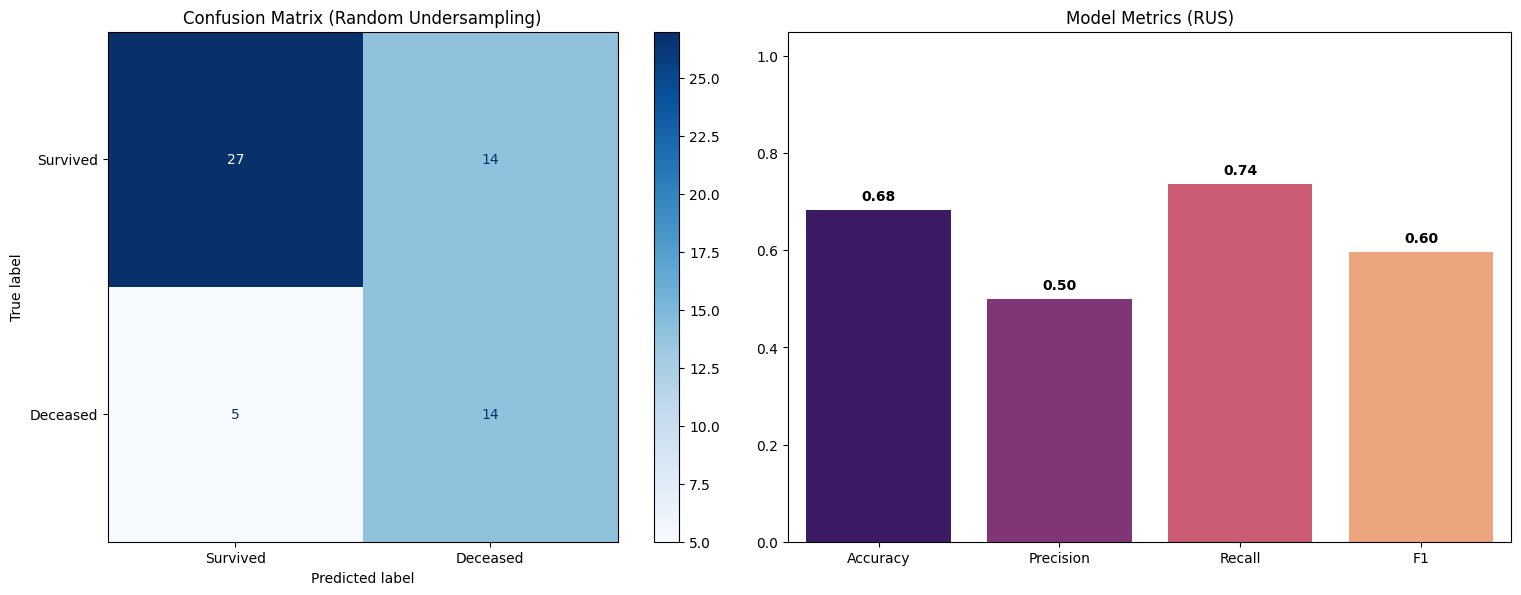

In [ ]:

y_pred_rus = best_rf_rus.predict(X_test_rus_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ConfusionMatrixDisplay.from_predictions(
    y_test_rus, y_pred_rus,
    display_labels=['Survived', 'Deceased'],
    cmap='Blues', ax=ax1
)
ax1.set_title("Confusion Matrix (Random Undersampling)")


metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1']
values_list = [
    accuracy_score(y_test_rus, y_pred_rus),
    precision_score(y_test_rus, y_pred_rus),
    recall_score(y_test_rus, y_pred_rus),
    f1_score(y_test_rus, y_pred_rus)
]

sns.barplot(x=metrics_list, y=values_list, palette='magma', ax=ax2)
ax2.set_ylim(0, 1.05)
ax2.set_title("Model Metrics (RUS)")
for i, v in enumerate(values_list):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Simplified Random Forest
Training a model using only the two most significant clinical features: Serum Creatinine and Ejection Fraction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


selected_features = ['serum_creatinine', 'ejection_fraction']
X_simple = df[selected_features].values.astype(np.float32)
y_simple = df[TARGET].values.astype(np.float32).ravel()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)


simple_rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}


gs_simple = GridSearchCV(RandomForestClassifier(random_state=42), simple_rf_params, cv=5, scoring='f1')
gs_simple.fit(X_train_s, y_train_s)

best_rf_simple = gs_simple.best_estimator_
print(f"Best Parameters: {gs_simple.best_params_}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}


# Neural Network

In [ ]:
data_dict = load_data(test_size=0.2, val_size=0.2, random_state=42)

X_train, y_train = data_dict['X_train'], data_dict['y_train']
X_val, y_val = data_dict['X_val'], data_dict['y_val']
X_test, y_test = data_dict['X_test'], data_dict['y_test']


print(f"Training set shape:   {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape:       {X_test.shape}, {y_test.shape}")

Training set shape:   (179, 11), (179,)
Validation set shape: (60, 11), (60,)
Test set shape:       (60, 11), (60,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),

        # Output layer for binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the model
input_dim = X_train.shape[1]
model = build_model(input_dim)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define EarlyStopping to prevent overfitting
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                            patience=20,
                                            restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[callback],
    verbose=0
)

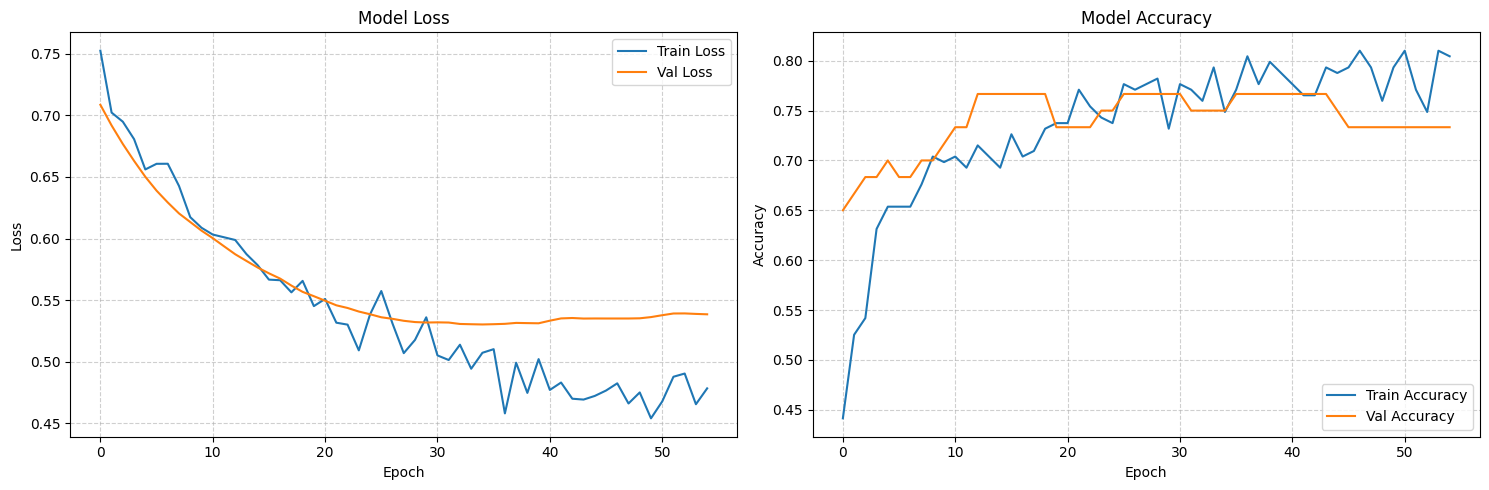

In [ ]:
# Plot training & validation loss/accuracy values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.83      0.79        41
         1.0       0.53      0.42      0.47        19

    accuracy                           0.70        60
   macro avg       0.64      0.63      0.63        60
weighted avg       0.69      0.70      0.69        60



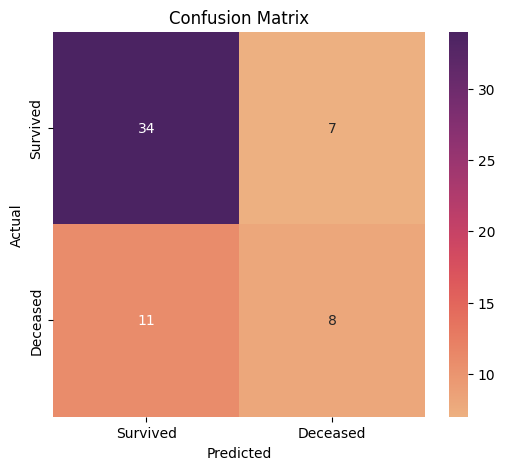

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Generate predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 2. Print Classification Report (Accuracy, F1-score, Recall, Precision)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='flare',
            xticklabels=['Survived', 'Deceased'],
            yticklabels=['Survived', 'Deceased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.utils import class_weight

# 1. Calculate class weights based on the training data distribution
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.flatten()
)
class_weight_dict = dict(enumerate(weights))

print(f"Calculated Class Weights: {class_weight_dict}")

# 2. Re-train the model with class weights
model_weighted = build_model(input_dim)

history_weighted = model_weighted.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[callback],
    verbose=0
)

# 3. Evaluate with a lower threshold (e.g., 0.3 instead of 0.5)
y_pred_weighted_probs = model_weighted.predict(X_test)
threshold = 0.3
y_pred_weighted = (y_pred_weighted_probs > threshold).astype(int)

print(f"\nClassification Report (Weighted + {threshold} Threshold):")
nn_report = classification_report(y_test, y_pred_weighted)
print(nn_report)

Calculated Class Weights: {0: np.float64(0.7396694214876033), 1: np.float64(1.543103448275862)}


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Classification Report (Weighted + 0.3 Threshold):
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        41
         1.0       0.32      1.00      0.48        19

    accuracy                           0.32        60
   macro avg       0.16      0.50      0.24        60
weighted avg       0.10      0.32      0.15        60



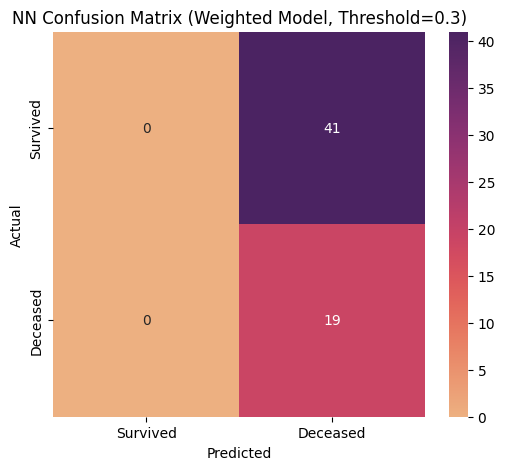

In [ ]:
 cm_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='flare',
            xticklabels=['Survived', 'Deceased'],
            yticklabels=['Survived', 'Deceased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'NN Confusion Matrix (Weighted Model, Threshold={threshold})')
plt.show()

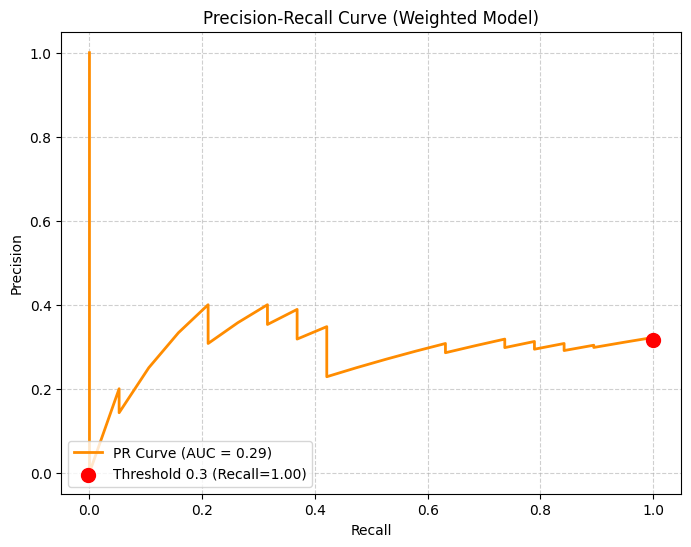

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision and recall for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_weighted_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='darkorange', lw=2)

# Plot the current operating point (threshold 0.3)
# Find index of threshold closest to 0.3
idx = np.argmin(np.abs(thresholds - 0.3))
plt.scatter(recall[idx], precision[idx], color='red', s=100, label=f'Threshold 0.3 (Recall={recall[idx]:.2f})', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Weighted Model)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.metrics import recall_score, precision_score, average_precision_score

# Calculate final metrics for the weighted model using the 0.3 threshold
final_recall = recall_score(y_test, y_pred_weighted)
final_precision = precision_score(y_test, y_pred_weighted)
final_auprc = average_precision_score(y_test, y_pred_weighted_probs)

print("--- Final Baseline Metrics (Weighted Neural Network) ---")
print(f"Recall:    {final_recall:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"AUPRC:     {final_auprc:.4f}")

--- Final Baseline Metrics (Weighted Neural Network) ---
Recall:    1.0000
Precision: 0.3167
AUPRC:     0.3143



Comparing Precision, Recall, and F1-Score for Survived (0) and Deceased (1) across Neural Networks.

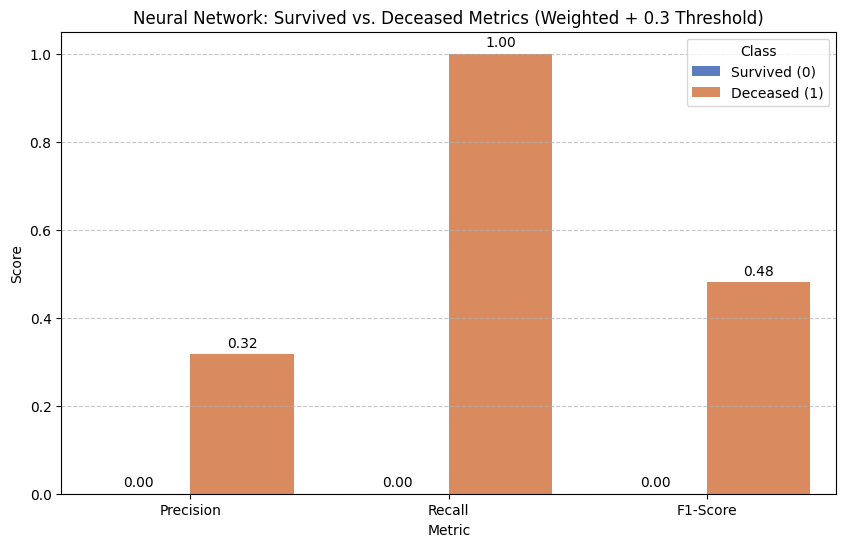

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

def plot_per_class_metrics(y_true, y_pred, title):
    metrics_per_class = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])
    data_list = []
    labels = ['Survived (0)', 'Deceased (1)']
    metric_names = ['Precision', 'Recall', 'F1-Score']

    for i, label in enumerate(labels):
        for j, metric in enumerate(metric_names):
            data_list.append({
                'Class': label,
                'Metric': metric,
                'Score': metrics_per_class[j][i]
            })

    metrics_df = pd.DataFrame(data_list)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Class', palette='muted')
    plt.ylim(0, 1.05)
    plt.title(title)
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.2f', padding=3)
    plt.show()


# 2. Neural Network (using the weighted model predictions from cell ZbOXBZVSIPCk)
plot_per_class_metrics(y_test, y_pred_weighted, 'Neural Network: Survived vs. Deceased Metrics (Weighted + 0.3 Threshold)')

# Compare results

In [ ]:
print("Classification Reports Across All Models:")
print("\nLogistic Regression Report:\n", logRegr_report)
print("\nSVM Report:\n", svm_report)
print("\nRandom Forest Report:\n", rf_report)
print("\nNeural Network Report:\n", nn_report)

Classification Reports Across All Models:

Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       0.76      0.68      0.72        41
         1.0       0.43      0.53      0.48        19

    accuracy                           0.63        60
   macro avg       0.60      0.60      0.60        60
weighted avg       0.65      0.63      0.64        60


SVM Report:
               precision    recall  f1-score   support

         0.0       0.76      0.71      0.73        41
         1.0       0.45      0.53      0.49        19

    accuracy                           0.65        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.67      0.65      0.66        60


Random Forest Report:
               precision    recall  f1-score   support

         0.0       0.85      0.80      0.82        41
         1.0       0.62      0.68      0.65        19

    accuracy                           0.77        60
   macro avg      

Overall random forest offers the best recall and overall scores (precision and F1).